In [ ]:
# uncomment this line if you need to install pyphyschemtools
# (remove "# " - don't forget to remove the empty space)
# 1. Force uninstall the old version completely
# !pip uninstall pyNanoMatBuilder -y

# 2. Install the new version with flags that bypass all caches and force a refresh
# !pip install --index-url https://test.pypi.org/simple/ pyNanoMatBuilder==0.9.0 --no-cache-dir --no-deps

# Optional: only necessary if you want to visualize 3D structures directly within the notebook.
# !pip install pyphyschemtools

<div class="rqT", title="📥 README first">

[**Click here: Local (cloning) *vs*. Google Colab**](./colab_vs_local.md)

if you choose a Google Colab cloud session, click on this icon (unless *you are already* in Google Colab):

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rpoteau/pyNanoMatBuilder/blob/main/pyNMB-examples.ipynb)

</div>

pyNanoMatBuilder: parallelism set to 4 threads.



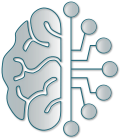

**Environment initialized:** Wednesday 20 May 2026, 11:30:25 on localhost.localdomain  
<span style='color: #007a7a; font-weight: bold;'>[OK] Parallel computing ENABLED (4 threads)</span>

pyNMB.__version__='0.12.3'


In [2]:
# # development purpose only. Comment these 2 lines on Google Colab
%load_ext autoreload
%autoreload 2
#------------------------------

##################
# Initialization #
##################
import pyNanoMatBuilder as pyNMB
pyNMB.set_threads(4)
pyNMB.init()
%matplotlib inline
print(f"{pyNMB.__version__=}")

from pyNanoMatBuilder import utils as pyNMBu

# Tutorials

## Evaluating relevant sizes to fit an experimental SAXS signal

### Context and workflow

<div class="intro">

A SAXS spectrum measured on a nanoparticle sample is never the signal of a single, perfectly monodisperse object. It is the weighted sum of contributions from particles of different sizes, distributed according to a size distribution (Gaussian, Schulz, etc.).
The goal of this section is to identify which discrete sizes are most relevant to reproduce and interpret an experimental SAXS spectrum, as a first step toward a full polydispersity-aware simulation. The overall workflow is:

1. Identify some characteristic sizes from the experimental distribution
2. Build the corresponding atomic structures with pyNanoMatBuilder and optimize them
3. Compute individual SAXS spectra for each structure, then sum them with the appropriate weights to reproduce the experimental spectrum

In this example, we work with **silver icosahedra** from the study of xxx et al. From SAXS experiments, after volumetric correction between spheres and icosahedra, the following parameters can be inferred:

- *&mu;*(exp) = 2.60 nm
- %PD = 11%

The size distribution is modeled here with a Schulz distribution, which is better suited than a Gaussian for SAXS/SANS experiments as it accounts for the natural asymmetry of nanoparticle size distributions (skewed toward larger sizes).
</div>

### Step 1. Identify some characteristic sizes from the experimental distribution

<div class="intro">

**(a) Theoretical Schulz distribution from SAXS fit**

From the experimental parameters, we build the theoretical Schulz distribution and identify the characteristic sizes at μ ± nσ. These sizes will serve as references for the atomic structures to be built and simulated in the following steps. The table shows, for each characteristic size, its relative weight in the distribution. Sizes close to μ carry the highest weight, while those beyond ±3σ contribute very little and can generally be neglected.

The next step will be to identify which nOrder values in pyNanoMatBuilder produce structures whose geometry, after optimization, best matches these target diameters. If perfect, defect-free icosahedra do not land close enough to the target sizes, structures with incomplete outer shells (surface peeling) will be considered as intermediate sizes between two consecutive magic numbers.
</div>

Label    | Diameter (nm)   | Ratio/Peak   | Est. Count   | Norm. (dist)   | Norm. (1)   
----------------------------------------------------------------------------------------
μ-4σ     |         1.46 nm |      0.000   |          0   |       0.0000   |     0.0000
μ-3σ     |         1.74 nm |      0.004   |          4   |       0.0018   |     0.0018
μ-2σ     |         2.03 nm |      0.122   |        122   |       0.0487   |     0.0486
μ-σ      |         2.31 nm |      0.655   |        655   |       0.2611   |     0.2610
μ        |         2.60 nm |      1.000   |       1000   |       0.3988   |     0.3986
μ+σ      |         2.89 nm |      0.565   |        565   |       0.2254   |     0.2253
μ+2σ     |         3.17 nm |      0.143   |        143   |       0.0569   |     0.0569
μ+3σ     |         3.46 nm |      0.019   |         19   |       0.0074   |     0.0074
μ+4σ     |         3.74 nm |      0.001   |          1   |       0.0005   |     0.0005
---------------------------------------

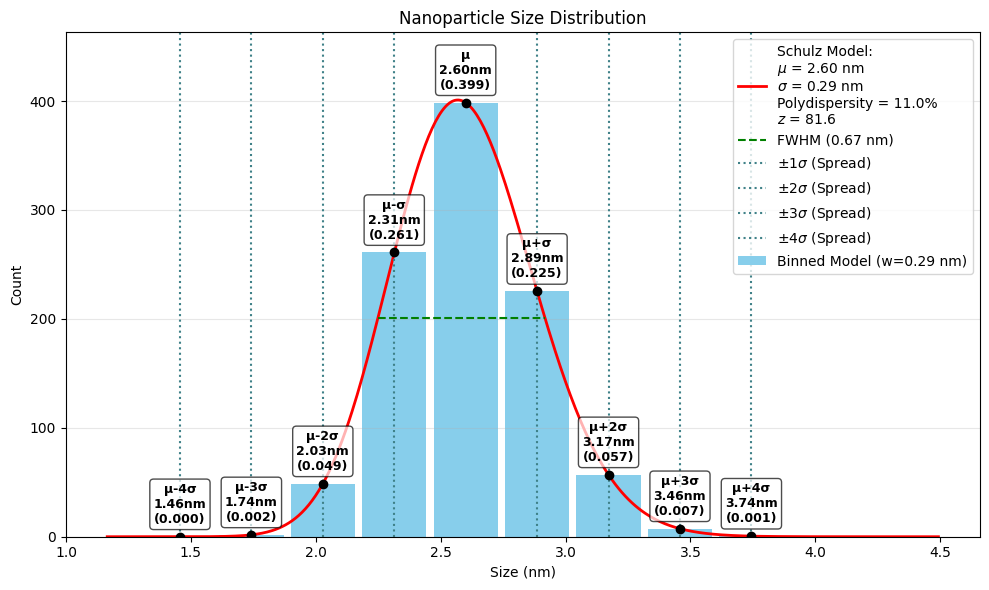

In [16]:
nd = pyNMBu.NanoparticleDistribution.from_polydispersity(mu=2.60, pd_pct=11, model="schulz")
nd.print_specific_proportions(nd.representative_sizes, nd.representative_labels)
nd.plot(highlight_sizes=[nd.representative_sizes, nd.representative_labels])

<div class="intro">

**(b) Convert the SAXS diameter to a core-to-core diameter**

The diameter measured by SAXS includes the electron density cloud around each surface atom. To compare it with the core-to-core dimensions produced by pyNanoMatBuilder, we subtract one atomic radius on each side:

$$D_\text{core}=D_\text{SAXS}−2×r_\text{Ag}$$

We first inspect the available atomic radii for silver:
</div>

In [17]:
Ag = pyNMBu.print_atomic_radii("Ag")
print()
print(Ag.metallic_radius)
print(Ag.get_ionic_radii(charge=+1, coordination='VI'))

Atomic radii for Silver (Ag)
──────────────────────────────────────────────────
  metallic_radius      :   134 pm  =  1.3400 Å
  covalent_radius      :   128 pm  =  1.2800 Å
  vdw_radius           :   211 pm  =  2.1100 Å
  atomic_radius        :   160 pm  =  1.6000 Å

  Ionic radii
  ──────────────────────────────────────────────
  Charge   Coord.   Spin         Radius (pm)    Radius (Å)
  ──────────────────────────────────────────────
      +1   II       n/a                67 pm   0.6700 Å
      +1   IV       n/a               100 pm   1.0000 Å
      +1   IVSQ     n/a               102 pm   1.0200 Å
      +1   V        n/a               109 pm   1.0900 Å
      +1   VI       n/a               115 pm   1.1500 Å
      +1   VII      n/a               122 pm   1.2200 Å
      +1   VIII     n/a               128 pm   1.2800 Å
      +2   IVSQ     n/a                79 pm   0.7900 Å
      +2   VI       n/a                94 pm   0.9400 Å
      +3   IVSQ     n/a                67 pm   0.6700 Å


<div class="intro">

For metallic nanoparticles, the metallic radius is the most physically meaningful choice — it reflects the actual atomic size in a crystalline metallic environment, and is consistent with the nearest-neighbor distance used internally by pyNanoMatBuilder (*Rnn* = 2 × *r*<sub>metallic</sub>).

We then rebuild the distribution using the corrected mean diameter — all sizes are now expressed as core-to-core distances, directly comparable to pyNanoMatBuilder output:
</div>

Label    | Diameter (nm)   | Ratio/Peak   | Est. Count   | Norm. (dist)   | Norm. (1)   
----------------------------------------------------------------------------------------
μ-4σ     |         1.31 nm |      0.000   |          0   |       0.0000   |     0.0000
μ-3σ     |         1.56 nm |      0.004   |          4   |       0.0018   |     0.0018
μ-2σ     |         1.82 nm |      0.122   |        122   |       0.0487   |     0.0486
μ-σ      |         2.08 nm |      0.655   |        655   |       0.2611   |     0.2610
μ        |         2.33 nm |      1.000   |       1000   |       0.3988   |     0.3986
μ+σ      |         2.59 nm |      0.565   |        565   |       0.2254   |     0.2253
μ+2σ     |         2.85 nm |      0.143   |        143   |       0.0569   |     0.0569
μ+3σ     |         3.10 nm |      0.019   |         19   |       0.0074   |     0.0074
μ+4σ     |         3.36 nm |      0.001   |          1   |       0.0005   |     0.0005
---------------------------------------

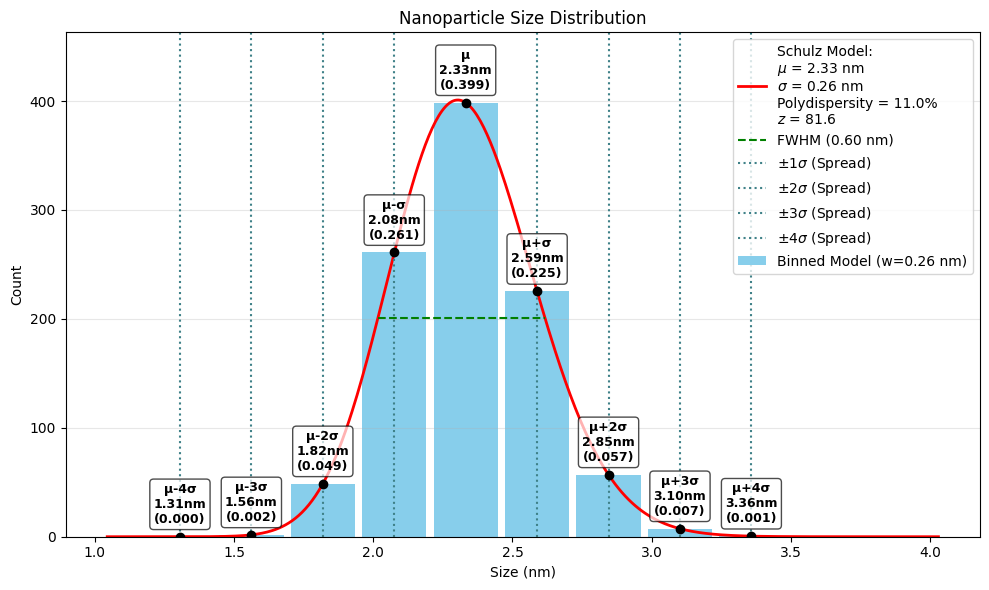

In [18]:
mu_core = 2.60-2*Ag.metallic_radius/10

nd = pyNMBu.NanoparticleDistribution.from_polydispersity(mu=mu_core, pd_pct=11, model="schulz")
nd.print_specific_proportions(nd.representative_sizes, nd.representative_labels)
nd.plot(highlight_sizes=[nd.representative_sizes,nd.representative_labels])

<div class="rqE">

These corrected diameters are the actual target sizes to match with pyNanoMatBuilder structures in Step 2.
</div>

### Step 2. Build the corresponding atomic structures with pyNanoMatBuilder and optimize them

#### Find the nOrder value that yields an icosahedral NP with diameter close to *μ*

<div class="intro">
The first step is to identify which nOrder values produce icosahedra whose diameter, after geometry optimization, falls close to the target sizes identified in Step 1. This is done by a manual trial-and-error exploration: we build a few icosahedra with increasing nOrder, optimize their geometry, and compare their actual dimensions to *μ* − *σ*, *μ*, and *μ* + *σ*.
Magic-number icosahedra being discrete objects, there is no guarantee that a perfect, defect-free structure will land exactly on a target size. Between two consecutive nOrder values, intermediate sizes can be reached by peeling the outermost atomic layer, removing atoms with the lowest coordination number. This gives access to a continuous range of sizes between two magic numbers.
</div>

Regular icosahedron with 5 shell(s) and Rnn = 2.7


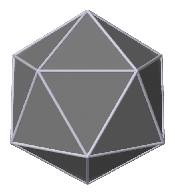

element =  Ag
number of vertices =  12
number of edges =  30
number of faces =  20
phi =  1.618033988749895
intershell factor = 1.05
nearest neighbour distance = 2.70 Å
intershell distance = 2.57 Å
edge length = 1.35 nm
radius after volume = 1.09 nm
radius of the circumscribed sphere = 1.28 nm
radius of the inscribed sphere = 1.02 nm
area = 15.8 nm2
volume = 5.4 nm3
number of atoms per shell =  [1, 12, 42, 92, 162, 252]
cumulative number of atoms per shell =  [1, 13, 55, 147, 309, 561]
total number of atoms =  561
Dual polyhedron: dodecahedron


Total number of atoms = 561
[1, 12, 42, 92, 162, 252]
Duration : 00:00:00 006ms


Moments of inertia = 3483379.35 3483379.35 3483379.35 amu.Å2
Moments of inertia / M = 57.56 57.56 57.56 amu.Å2
Moments of inertia with mass=1/M = 57.56 57.56 57.56 Å2


 Principal Moments : I1=57.56, I2=57.56, I3=57.56
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 9.3 nm


...

 Rg = 10.1 nm


Found:
  - 252 vertices
  - 500 simplices
  - Volume: 6.87 nm³
  - Area: 18.32 nm²
Duration : 00:00:00 002ms


252 atoms lie in the plane(s)
Duration : 00:00:00 006ms


Diameter of the circumscribed sphere: 27.34 Å
Diameter of the inscribed sphere: 22.36 Å


  - Dimensions (Å): 27.34 x 27.34 x 27.34
  - Volume: 10.70 nm³
  - Surface: 23.48 nm²
  - Asphericity: 1.00
  - Max Radius found: 1.367 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {13.670655 0.000000 0.000000} {-0.000000 12.250192 6.067916} {0.000000 6.067916 -12.250192}; ellipsoid ID optimized_structure_el CENTER {-0.000 0.000 -0.000}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:02 183ms


In [19]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

ico = pNP.regIco("Ag",
                 2.7,
                 5,
                 skipSymmetryAnalyzis=True,
                 noOutput=False
                )

pyNMBu.write(f"coords/ico.xyz", ico.NP)
pyNMBu.write(f"coords/ico_cs.xyz", ico.NPcs)
pyNMBu.write(f"coords/ico.script", ico.jMolCS)
ico.get_ellipsoid_analysis(mode="vertices")
ico.get_ellipsoid_analysis(mode="planes")
ico.get_ellipsoid_analysis(mode="all")
ico.optimize()
pyNMBu.write(f"coords/ico_opt.xyz", ico.NP_opt)
pyNMBu.write(f"coords/ico_cs_opt.xyz", ico.NPcs_opt)

####  Bracketing around the 4-shell icosahedron

<div class="intro">

We will now systematically build and optimize icosahedra from 2 to 7 shells to bracket structures around the target size, and to evaluate what would be their weight in a weighted sum of individual SAXS signals.
</div>

In [20]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the number of shells
nshells=range(2,8)
D = []
labels = []
for nshell in nshells:
    name=f"ico_{nshell:02d}"
    pyNMBu.centerTitle(name)
    ico = pNP.regIco("Ag",
                     2.7,
                     nshell,
                     skipSymmetryAnalyzis=True,
                     noOutput=True
                    )
    
    pyNMBu.write(f"coords/{name}.xyz", ico.NP)
    ico.optimize(noOutput=True)
    d = ico.effective_diameter(structure='optimized', mode='vertices')  # nm
    D.append(d)
    print(f"nOrder {nshell:<2}. nAtoms: {ico.nAtoms:<5}. D = {d: .2f} nm")
    pyNMBu.write(f"coords/{name}_opt.xyz", ico.NP_opt)
    labels.append(f"{nshell:<2} sh.")

print(D)
print(labels)

N atoms: 55
Positions range: min [-4.36869177 -4.36869177 -4.36869177]  max [4.36869177 4.36869177 4.36869177]
Cell: Cell([0.0, 0.0, 0.0])
PBC flags: [False False False]
Pairwise dmin=2.5679 Å, dmean=5.6681 Å
Diagnostics OK (no obvious fatal problems found).
                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 11:48:56       31.212727       2.4888
BFGSLineSearch:    1[  1] 11:48:57       23.954186       4.5237
BFGSLineSearch:    2[  2] 11:48:57       17.789497       0.8437
BFGSLineSearch:    3[  3] 11:48:57       17.535119       0.3591
BFGSLineSearch:    4[  4] 11:48:57       17.474512       0.0457
Duration : 00:00:00 056ms
nOrder 2 . nAtoms: 55   . D =  1.09 nm


N atoms: 147
Positions range: min [-6.55303765 -6.55303765 -6.55303765]  max [6.55303765 6.55303765 6.55303765]
Cell: Cell([0.0, 0.0, 0.0])
PBC flags: [False False False]
Pairwise dmin=2.5679 Å, dmean=7.8848 Å
Diagnostics OK (no obvious fatal problems found).
                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 11:48:57       80.141346       2.7001
BFGSLineSearch:    1[  1] 11:48:57       57.738340       2.4110
BFGSLineSearch:    2[  2] 11:48:57       42.233074       3.3130
BFGSLineSearch:    3[  3] 11:48:57       35.231519       0.4843
BFGSLineSearch:    4[  4] 11:48:57       34.050496       0.2071
BFGSLineSearch:    5[  5] 11:48:57       33.905959       0.0507
Duration : 00:00:00 183ms
nOrder 3 . nAtoms: 147  . D =  1.63 nm


N atoms: 309
Positions range: min [-8.73738354 -8.73738354 -8.73738354]  max [8.73738354 8.73738354 8.73738354]
Cell: Cell([0.0, 0.0, 0.0])
PBC flags: [False False False]
Pairwise dmin=2.5679 Å, dmean=10.1182 Å
Diagnostics OK (no obvious fatal problems found).
                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 11:48:57      165.228073       2.7018
BFGSLineSearch:    1[  1] 11:48:57      121.085618       2.4504
BFGSLineSearch:    2[  2] 11:48:57      100.871151       5.6999
BFGSLineSearch:    3[  3] 11:48:57       81.222434       7.5421
BFGSLineSearch:    4[  4] 11:48:57       62.139671       2.1306
BFGSLineSearch:    5[  5] 11:48:57       57.152578       0.9668
BFGSLineSearch:    6[  6] 11:48:57       56.249104       0.4101
BFGSLineSearch:    7[  7] 11:48:57       56.104868       0.1665
BFGSLineSearch:    8[  8] 11:48:57       56.065677       0.0364
Duration : 00:00:01 621ms
nOrder 4 . nAtoms: 309  . D =  2.19 nm


N atoms: 561
Positions range: min [-10.92172942 -10.92172942 -10.92172942]  max [10.92172942 10.92172942 10.92172942]
Cell: Cell([0.0, 0.0, 0.0])
PBC flags: [False False False]
Pairwise dmin=2.5679 Å, dmean=12.3578 Å
Diagnostics OK (no obvious fatal problems found).
                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 11:48:57      296.684774       2.7033
BFGSLineSearch:    1[  1] 11:48:58      223.571439       2.4488
BFGSLineSearch:    2[  2] 11:48:58      180.073203       3.4268
BFGSLineSearch:    3[  3] 11:48:58      146.425260       6.4171
BFGSLineSearch:    4[  4] 11:48:58      116.170249       2.6919
BFGSLineSearch:    5[  5] 11:48:59       95.276811       1.0123
BFGSLineSearch:    6[  6] 11:48:59       86.482426       0.4221
BFGSLineSearch:    7[  7] 11:48:59       84.660308       0.2799
BFGSLineSearch:    8[  8] 11:48:59       84.321348       0.1270
BFGSLineSearch:    9[  9] 11:48:59       84.236133       0.0725
Duration : 00:00:02 175ms
nO

N atoms: 923
Positions range: min [-13.10607531 -13.10607531 -13.10607531]  max [13.10607531 13.10607531 13.10607531]
Cell: Cell([0.0, 0.0, 0.0])
PBC flags: [False False False]
Pairwise dmin=2.5679 Å, dmean=14.6003 Å
Diagnostics OK (no obvious fatal problems found).
                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 11:49:00      484.723319       2.7048
BFGSLineSearch:    1[  1] 11:49:00      375.412216       2.4474
BFGSLineSearch:    2[  2] 11:49:01      303.636724       3.3878
BFGSLineSearch:    3[  3] 11:49:02      265.696356       6.2040
BFGSLineSearch:    4[  4] 11:49:02      225.184760       4.2587
BFGSLineSearch:    5[  6] 11:49:03      167.655936       7.7850
BFGSLineSearch:    6[  7] 11:49:04      139.057921       1.2763
BFGSLineSearch:    7[  8] 11:49:05      124.106795       0.5791
BFGSLineSearch:    8[  9] 11:49:06      119.492165       0.2242
BFGSLineSearch:    9[ 10] 11:49:07      118.827505       0.1363
BFGSLineSearch:   10[ 12] 11

N atoms: 1415
Positions range: min [-15.29042119 -15.29042119 -15.29042119]  max [15.29042119 15.29042119 15.29042119]
Cell: Cell([0.0, 0.0, 0.0])
PBC flags: [False False False]
Pairwise dmin=2.5679 Å, dmean=16.8441 Å
Diagnostics OK (no obvious fatal problems found).
                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 11:49:09      739.555577       2.7048
BFGSLineSearch:    1[  1] 11:49:09      586.795441       2.4474
BFGSLineSearch:    2[  2] 11:49:12      479.571607       3.3325
BFGSLineSearch:    3[  3] 11:49:15      411.765182       5.5923
BFGSLineSearch:    4[  4] 11:49:17      367.592597       6.9603
BFGSLineSearch:    5[  6] 11:49:20      292.672000       6.5321
BFGSLineSearch:    6[  8] 11:49:23      209.206249       2.3464
BFGSLineSearch:    7[  9] 11:49:25      183.150540       1.1682
BFGSLineSearch:    8[ 10] 11:49:28      166.640868       0.4620
BFGSLineSearch:    9[ 11] 11:49:31      160.543622       0.3444
BFGSLineSearch:   10[ 12] 1

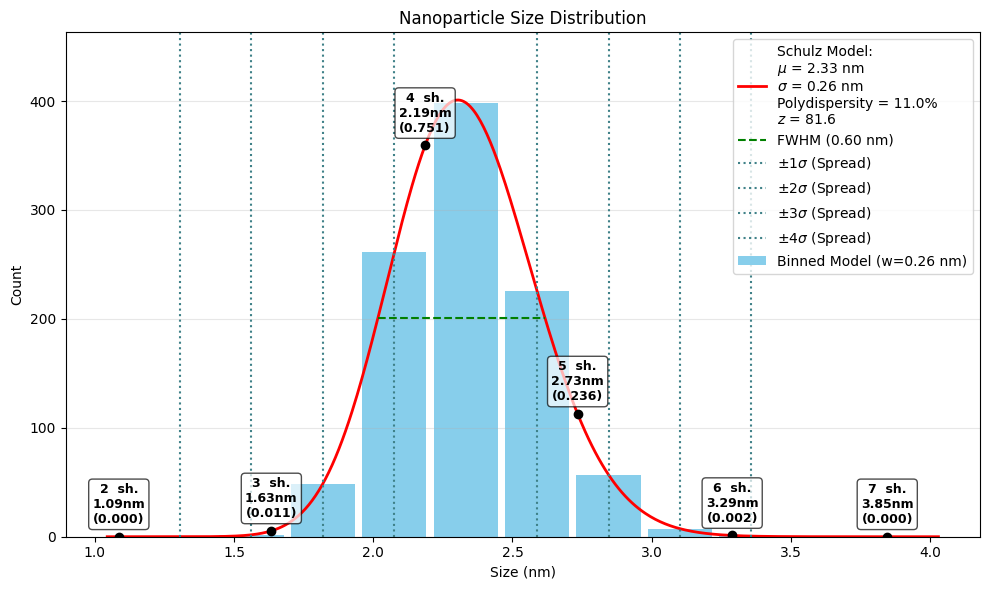

In [21]:
nd.plot(highlight_sizes=[D, labels])

<div class="rqE">

The figure above shows the Schulz size distribution with the magic-number icosahedra superimposed. Two perfect structures bracket the mean: the 4-shell icosahedron at 2.19 nm (weight 0.751) lies close to μ, while the 5-shell at 2.73 nm (weight 0.236) sits near μ+2σ. No perfect icosahedron falls on μ−σ or μ+σ.

To fill these gaps, we will use `peel_by_shifted_ellipsoid()`, which generates icosahedra with an incomplete outer shell by shifting the center of the truncating ellipsoid. This approach is more physically realistic than simple coordination-number peeling, as it produces smooth, faceted surface truncations similar to those expected from growth kinetics. Starting from the 4-shell structure, we will progressively remove part of the outer layer to reach ~2.08 nm (*μ*−*σ*); similarly, starting from the 5-shell, we will target ~2.59 nm (*μ*+*σ*). After geometry optimization, the actual dimensions will be measured and the exact SAXS weights computed.

</div>

#### Build intermediate structures, *i.e.* icosahedra with a partially filled outer shell

In [22]:
DNew = D.copy()
labelsNew = labels.copy()

In [23]:
pyNMBu.centerTitle("4 shells (1)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.peel_by_shifted_ellipsoid(shift_dist=3, noOutput=False)
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/ico_04p1.xyz", ico4p.NP)
pyNMBu.write("coords/ico_04p1.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()
print(f"Average diameter = {ico4p_D:.2f} nm")
pyNMBu.write("coords/ico_04p1_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/ico_04p1_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/ico_04p1_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append("4 sh. p1")

Moments of inertia = 1497605.82 1497605.82 1497605.82 amu.Å2
Moments of inertia / M = 44.93 44.93 44.93 amu.Å2
Moments of inertia with mass=1/M = 44.93 44.93 44.93 Å2


 Principal Moments : I1=44.93, I2=44.93, I3=44.93
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 8.2 nm


Found:
  - 162 vertices
  - 320 simplices
  - Volume: 3.50 nm³
  - Area: 11.70 nm²
Duration : 00:00:00 002ms


162 atoms lie in the plane(s)
Duration : 00:00:00 005ms


...

 Rg = 7.7 nm


Found:
  - 118 vertices
  - 232 simplices
  - Volume: 2.93 nm³
  - Area: 10.38 nm²
Duration : 00:00:00 002ms


134 atoms lie in the plane(s)
Duration : 00:00:00 003ms


Diameter of the circumscribed sphere: 21.49 Å
Diameter of the inscribed sphere: 15.30 Å


  - Dimensions (Å): 21.35 x 21.05 x 19.84
  - Volume: 4.67 nm³
  - Surface: 13.52 nm²
  - Asphericity: 1.08
  - Max Radius found: 1.068 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {9.702918 2.240464 3.852528} {3.124942 -9.815197 -2.162336} {-2.910557 -2.915078 9.025768}; ellipsoid ID optimized_structure_el CENTER {0.284 0.337 -0.900}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:00 350ms
Average diameter = 2.07 nm


In [24]:
pyNMBu.centerTitle("4 shells (2)")
import pyNanoMatBuilder as pyNMB
ico4p = pyNMB.from_file("coords/ico_04_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico4p.peel_by_shifted_ellipsoid(shift_dist=5, noOutput=False)
ico4p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/ico_04p2.xyz", ico4p.NP)
pyNMBu.write("coords/ico_04p2.script", ico4p.jMolCS)
ico4p.optimize()
ico4p_D = ico4p.effective_diameter()
print(f"Average diameter = {ico4p_D:.2f} nm")
pyNMBu.write("coords/ico_04p2_opt.xyz", ico4p.NP_opt)
pyNMBu.write("coords/ico_04p2_opt.script", ico4p.jMolCS_opt)
pyNMBu.write("coords/ico_04p2_CS_opt.xyz", ico4p.NPcs_opt)

DNew.append(ico4p_D)
labelsNew.append("4 sh. p2")

Moments of inertia = 1497605.82 1497605.82 1497605.82 amu.Å2
Moments of inertia / M = 44.93 44.93 44.93 amu.Å2
Moments of inertia with mass=1/M = 44.93 44.93 44.93 Å2


 Principal Moments : I1=44.93, I2=44.93, I3=44.93
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 8.2 nm


Found:
  - 162 vertices
  - 320 simplices
  - Volume: 3.50 nm³
  - Area: 11.70 nm²
Duration : 00:00:00 002ms


162 atoms lie in the plane(s)
Duration : 00:00:00 004ms


...

 Rg = 7.3 nm


Found:
  - 100 vertices
  - 196 simplices
  - Volume: 2.38 nm³
  - Area: 9.08 nm²
Duration : 00:00:00 002ms


117 atoms lie in the plane(s)
Duration : 00:00:00 003ms


Diameter of the circumscribed sphere: 20.44 Å
Diameter of the inscribed sphere: 13.31 Å


  - Dimensions (Å): 20.64 x 20.06 x 16.82
  - Volume: 3.65 nm³
  - Surface: 11.53 nm²
  - Asphericity: 1.23
  - Max Radius found: 1.032 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {-2.576138 9.169409 3.971609} {8.912320 3.692641 -2.744474} {-3.235637 2.301051 -7.411285}; ellipsoid ID optimized_structure_el CENTER {-0.457 0.303 -0.850}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:00 385ms
Average diameter = 1.91 nm


In [25]:
pyNMBu.centerTitle("5 shells")
import pyNanoMatBuilder as pyNMB
ico5p = pyNMB.from_file("coords/ico_05_opt.xyz", skipSymmetryAnalyzis=True, skipFacetInfo=True)
ico5p.peel_by_shifted_ellipsoid(shift_dist=3, noOutput=False)
ico5p.peel_by_coordination(threshold_peeling=4, noOutput=False)
pyNMBu.write("coords/ico_05p.xyz", ico5p.NP)
pyNMBu.write("coords/ico_05p.script", ico5p.jMolCS)
ico5p.optimize()
ico5p_D = ico5p.effective_diameter()
print(f"Average diameter = {ico5p_D:.2f} nm")
pyNMBu.write("coords/ico_05p_opt.xyz", ico5p.NP_opt)
pyNMBu.write("coords/ico_05p_opt.script", ico5p.jMolCS_opt)
pyNMBu.write("coords/ico_05p_CS_opt.xyz", ico5p.NPcs_opt)

DNew.append(ico5p_D)
labelsNew.append("5 sh. p")

Moments of inertia = 4080085.11 4080085.11 4080085.11 amu.Å2
Moments of inertia / M = 67.42 67.42 67.42 amu.Å2
Moments of inertia with mass=1/M = 67.42 67.42 67.42 Å2


 Principal Moments : I1=67.42, I2=67.42, I3=67.42
 NPR1 (I1/I3)      : 1.0000
 NPR2 (I2/I3)      : 1.0000
 Predicted Shape   : Spherical/Symmetric


 Rg = 10.1 nm


Found:
  - 252 vertices
  - 500 simplices
  - Volume: 6.87 nm³
  - Area: 18.32 nm²
Duration : 00:00:00 003ms


252 atoms lie in the plane(s)
Duration : 00:00:00 007ms


...

 Rg = 9.7 nm


Found:
  - 202 vertices
  - 400 simplices
  - Volume: 6.18 nm³
  - Area: 17.02 nm²
Duration : 00:00:00 002ms


220 atoms lie in the plane(s)
Duration : 00:00:00 005ms


Diameter of the circumscribed sphere: 27.12 Å
Diameter of the inscribed sphere: 20.09 Å


  - Dimensions (Å): 26.88 x 26.15 x 23.87
  - Volume: 8.78 nm³
  - Surface: 20.63 nm²
  - Asphericity: 1.13
  - Max Radius found: 1.344 nm

  [Jmol Command to visualize the ellipsoid]:
  ellipsoid ID optimized_structure_el AXES {5.807027 -12.003018 -1.697042} {-6.872856 -4.746984 10.057073} {8.744337 3.173805 7.473802}; ellipsoid ID optimized_structure_el CENTER {0.825 0.221 0.654}; color $optimized_structure_el [x919191] translucent 0.3;
Duration : 00:00:01 484ms
Average diameter = 2.56 nm


#### Evaluate the relevance of the intermediate structures

<div class="intro">

We now overlay all the computed structures on the size distribution to visualize their positions and relative weights. `get_proportions()` returns, for each structure, its weight in the distribution, *i.e.* how much it would contribute to a weighted sum of individual SAXS signals.

Structures with negligible weight (close to 0) can be safely ignored in the SAXS simulation. In the next step, we filter out structures below a significance threshold and renormalize the remaining weights.
</div>

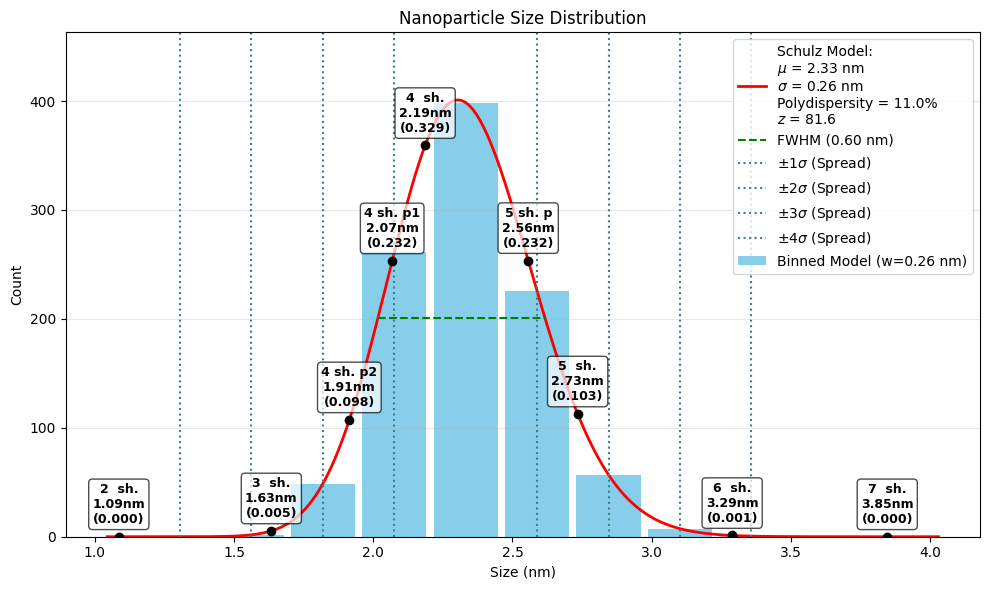

{'sizes': array([1.08639009, 1.63414723, 2.18628268, 2.7341311 , 3.28900531,
       3.84589404, 2.06800922, 1.91428009, 2.55653396]), 'labels': ['2  sh.', '3  sh.', '4  sh.', '5  sh.', '6  sh.', '7  sh.', '4 sh. p1', '4 sh. p2', '5 sh. p'], 'ratios': array([1.21990408e-08, 1.35443702e-02, 9.01340612e-01, 2.82905454e-01,
       2.90465889e-03, 2.74342958e-06, 6.35651539e-01, 2.69371810e-01,
       6.36311308e-01]), 'counts': array([1.21990408e-05, 1.35443702e+01, 9.01340612e+02, 2.82905454e+02,
       2.90465889e+00, 2.74342958e-03, 6.35651539e+02, 2.69371810e+02,
       6.36311308e+02]), 'norms': array([4.86462407e-09, 5.40110247e-03, 3.59428524e-01, 1.12814499e-01,
       1.15829382e-03, 1.09400024e-06, 2.53479419e-01, 1.07417674e-01,
       2.53742515e-01]), 'norms_relative': array([4.44890452e-09, 4.93953671e-03, 3.28712592e-01, 1.03173632e-01,
       1.05930870e-03, 1.00050950e-06, 2.31817652e-01, 9.82380076e-02,
       2.32058266e-01])}


In [26]:
nd.plot(highlight_sizes=[DNew, labelsNew])
data = nd.get_proportions(DNew, labelsNew)
print(data)

#### Filter only structures with significant weight

<div class="intro">

Weights are stored in `data_filtered['norms_relative'])`
</div>

{'sizes': array([1.91428009, 2.06800922, 2.18628268, 2.55653396, 2.7341311 ]), 'labels': ['4 sh. p2', '4 sh. p1', '4  sh.', '5 sh. p', '5  sh.'], 'ratios': array([0.26937181, 0.63565154, 0.90134061, 0.63631131, 0.28290545]), 'counts': array([269.37181019, 635.65153875, 901.34061225, 636.31130773,
       282.90545368]), 'norms': array([0.10741767, 0.25347942, 0.35942852, 0.25374252, 0.1128145 ]), 'norms_relative': array([0.09883098, 0.23321692, 0.33069672, 0.23345898, 0.1037964 ])}
[0.09883098 0.23321692 0.33069672 0.23345898 0.1037964 ]


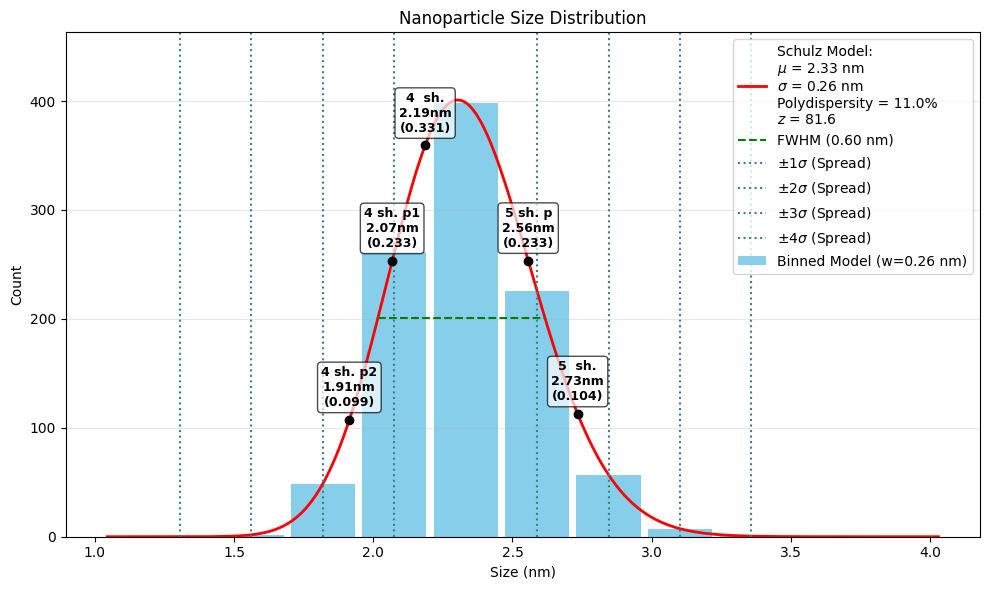

In [29]:
data_filtered = nd.filter_proportions(data, threshold=0.01)
print(data_filtered)
print(data_filtered['norms_relative'])
nd.plot(highlight_sizes=[data_filtered['sizes'], data_filtered['labels']])

In [30]:
pyNMB.end()

**End at:** Wednesday 20 May 2026, 11:51:46  
**Duration:** 00:21:21 965ms

# End